# ACT Demo: Fuzzing + Verification with VNNLib

Complete workflow using ACT framework with VNNLib benchmarks:
1. **Fuzzing**: ACTFuzzer for whitebox fuzzing
2. **Verification**: IntervalTF (forward bounds) + DualTF (certified bounds)
3. **Analysis**: Spurious counterexample inference

In [10]:
# Setup and imports
import sys, os 
import io
from contextlib import redirect_stdout

f = io.StringIO()
with redirect_stdout(f):
    from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
    from act.front_end.model_synthesis import synthesize_models_from_specs
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import torch
import matplotlib.pyplot as plt
import numpy as np
import yaml
from pathlib import Path
from collections import Counter

# Force reload modules
import importlib
modules_to_reload = [
    'act.pipeline.fuzzing.mutations',
    'act.pipeline.fuzzing.coverage',
    'act.pipeline.fuzzing.corpus',
    'act.pipeline.fuzzing.checker',
    'act.pipeline.fuzzing.actfuzzer',
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.fuzzing.actfuzzer import ACTFuzzer, FuzzingConfig
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.dual_tf import DualTF, compute_forward_bounds

# CIFAR-100 class names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("Setup complete")

Setup complete


## Step 1: Load VNNLib Benchmark and Synthesize Models

In [2]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

# Load VNNLib instances
creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=3,
    validate_shapes=True
)
print(f"Loaded {len(spec_results)} instances\n")

# Synthesize wrapped models
print("Synthesizing wrapped models...")
wrapped_models, reports = synthesize_models_from_specs(spec_results)
print(f"Synthesized {len(wrapped_models)} wrapped models\n")

# Extract instance info for all models
instance_info = []
wrapped_models_list = list(wrapped_models.values())
combo_ids = list(wrapped_models.keys())

for idx, (combo_id, wrapped_model) in enumerate(wrapped_models.items()):
    input_layer = wrapped_model[0]
    labeled_input = input_layer.labeled_input
    input_spec_layer = wrapped_model[1]
    input_spec = input_spec_layer.spec
    epsilon = float((input_spec.ub - input_spec.lb).max())
    
    instance_info.append({
        'index': idx,
        'combo_id': combo_id,
        'input_tensor': labeled_input.tensor,
        'true_label': labeled_input.label,
        'epsilon': epsilon,
        'input_spec': input_spec,
        'labeled_input': labeled_input
    })
    print(f"Instance {idx+1}: {CIFAR100_CLASSES[labeled_input.label]} (label={labeled_input.label}), eps={epsilon:.6f}")

print(f"\nReady for fuzzing and verification")

INFO:act.front_end.vnnlib_loader.create_specs:Creating VNNLIB specs: categories=['cifar100_2024'], max_instances=3
INFO:act.front_end.vnnlib_loader.create_specs:Processing 3 VNNLIB instances
INFO:act.front_end.vnnlib_loader.create_specs:Loading instance: cifar100_2024/CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_116_sidx_8002_eps_0.0039
INFO:act.front_end.vnnlib_loader.data_model_loader:Loading VNNLIB instance: cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:[1/3] Converting ONNX model to PyTorch...
INFO:act.front_end.vnnlib_loader.onnx_converter:Loading ONNX model from /data1/guanqin/newACT/ACT/data/vnnlib/cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.onnx_converter:Converting ONNX to PyTorch
INFO:act.front_end.vnnlib_loader.onnx_converter:Converted model to device=cpu, dtype=torch.float64
INFO:act.front_end.vnnlib_loader.onnx_converter:Successfully converted ONNX model: CIFAR100_resnet_mediu

LOADING CIFAR-100 VNNLIB BENCHMARK


INFO:act.front_end.vnnlib_loader.create_specs:Loading instance: cifar100_2024/CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4071_sidx_6244_eps_0.0039
INFO:act.front_end.vnnlib_loader.data_model_loader:Loading VNNLIB instance: cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:[1/3] Converting ONNX model to PyTorch...
INFO:act.front_end.vnnlib_loader.onnx_converter:Loading ONNX model from /data1/guanqin/newACT/ACT/data/vnnlib/cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.onnx_converter:Converting ONNX to PyTorch
INFO:act.front_end.vnnlib_loader.onnx_converter:Converted model to device=cpu, dtype=torch.float64
INFO:act.front_end.vnnlib_loader.onnx_converter:Successfully converted ONNX model: CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:  ✓ Model converted successfully
INFO:act.front_end.vnnlib_loader.data_model_loader:[2/3] Extracting input shape...
INFO:act.front_e

Loaded 3 instances

Synthesizing wrapped models...

🧬 Synthesizing models from 3 spec result(s)...
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_116_sidx_8002_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4071_sidx_6244_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_1862_sidx_1111_eps_0.0039: Created 1 wrapped model(s)

🎉 Synthesized 3 wrapped models from specs!
Synthesized 3 wrapped models

Instance 1: tank (label=85), eps=0.030590
Instance 2: shrew (label=74), eps=0.030590
Instance 3: table (label=84), eps=0.030590

Ready for fuzzing and verification


## Step 2: Fuzzing with ACTFuzzer

In [3]:
print("="*80)
print("RUNNING FUZZING")
print("="*80)

# Load fuzzing config
config_path = Path(act_root) / "act/pipeline/fuzzing/config.yaml"
with open(config_path) as f:
    yaml_config = yaml.safe_load(f)['fuzzing']

# Create config with 60s timeout per instance
config = FuzzingConfig(
    max_iterations=yaml_config['max_iterations'],
    timeout_seconds=60.0,
    device="cuda" if torch.cuda.is_available() else "cpu",
    save_counterexamples=yaml_config['save_counterexamples'],
    output_dir=Path("fuzzing_results_demo"),
    report_interval=yaml_config['report_interval'],
    mutation_weights=yaml_config['mutation_weights'],
    coverage_strategy=yaml_config['coverage_strategy'],
    activation_threshold=yaml_config['activation_threshold'],
    trace_level=1,
    trace_sample_rate=10,
)

print(f"Config: timeout={config.timeout_seconds}s, device={config.device}")
print(f"Mutation weights: {config.mutation_weights}\n")

# Fuzz each instance
all_reports = []
all_fuzzers = []

for idx, info in enumerate(instance_info):
    wrapped_model = wrapped_models_list[idx]
    labeled_input = info['labeled_input']
    
    print(f"\n[{idx+1}/{len(instance_info)}] Fuzzing: {CIFAR100_CLASSES[info['true_label']]}")
    
    fuzzer = ACTFuzzer(
        wrapped_model=wrapped_model,
        initial_seeds=[labeled_input],
        config=config
    )
    report = fuzzer.fuzz()
    all_reports.append(report)
    all_fuzzers.append(fuzzer)
    
    print(f"   Iterations: {report.total_iterations}, Counterexamples: {len(report.counterexamples)}")

# Aggregate results
print("\n" + "="*80)
print("FUZZING COMPLETE")
print("="*80)
total_iterations = sum(r.total_iterations for r in all_reports)
total_time = sum(r.total_time for r in all_reports)
total_counterexamples = sum(len(r.counterexamples) for r in all_reports)
avg_coverage = sum(r.neuron_coverage for r in all_reports) / len(all_reports)

print(f"Total iterations: {total_iterations} ({total_iterations / total_time:.1f} it/s)")
print(f"Total time: {total_time:.2f}s")
print(f"Total counterexamples: {total_counterexamples}")
print(f"Average coverage: {avg_coverage:.2%}")

RUNNING FUZZING
Config: timeout=60.0s, device=cpu
Mutation weights: {'gradient': 0, 'pgd': 0.4, 'activation': 0.3, 'boundary': 0.2, 'random': 0.1}


[1/3] Fuzzing: tank
[MutationEngine] Adaptive Scalar Perturbation Size:
  - perturb_scale: 0.1 (fraction of range per perturbation)
  - mean_range: 0.029446
  - computed perturb_size: 0.002945
  - steps_to_traverse: ~10.0 steps
  - interpretation: Each mutation perturbation covers 10.0% of the range
📊 Tracing enabled: Level 1, sampling every 10 iteration(s)
   Output: fuzzing_results_demo/traces.json
ACT: Abstract Constraint Transformer
Inference-based whitebox fuzzing for neural network verification

🚀 Starting ACTFuzzer with 1 seeds
   Device: cpu
   Max iterations: 10000
   Timeout: 60.0s

🚨 Counterexample #1: TOP1_ROBUST: expected 85, got 89 (conf=0.309)
🚨 Counterexample #2: TOP1_ROBUST: expected 85, got 89 (conf=0.309)
🚨 Counterexample #3: TOP1_ROBUST: expected 85, got 89 (conf=0.309)
🚨 Counterexample #4: TOP1_ROBUST: expected 85, got

## Step 3: Fuzzing Visualization

FUZZING VISUALIZATION


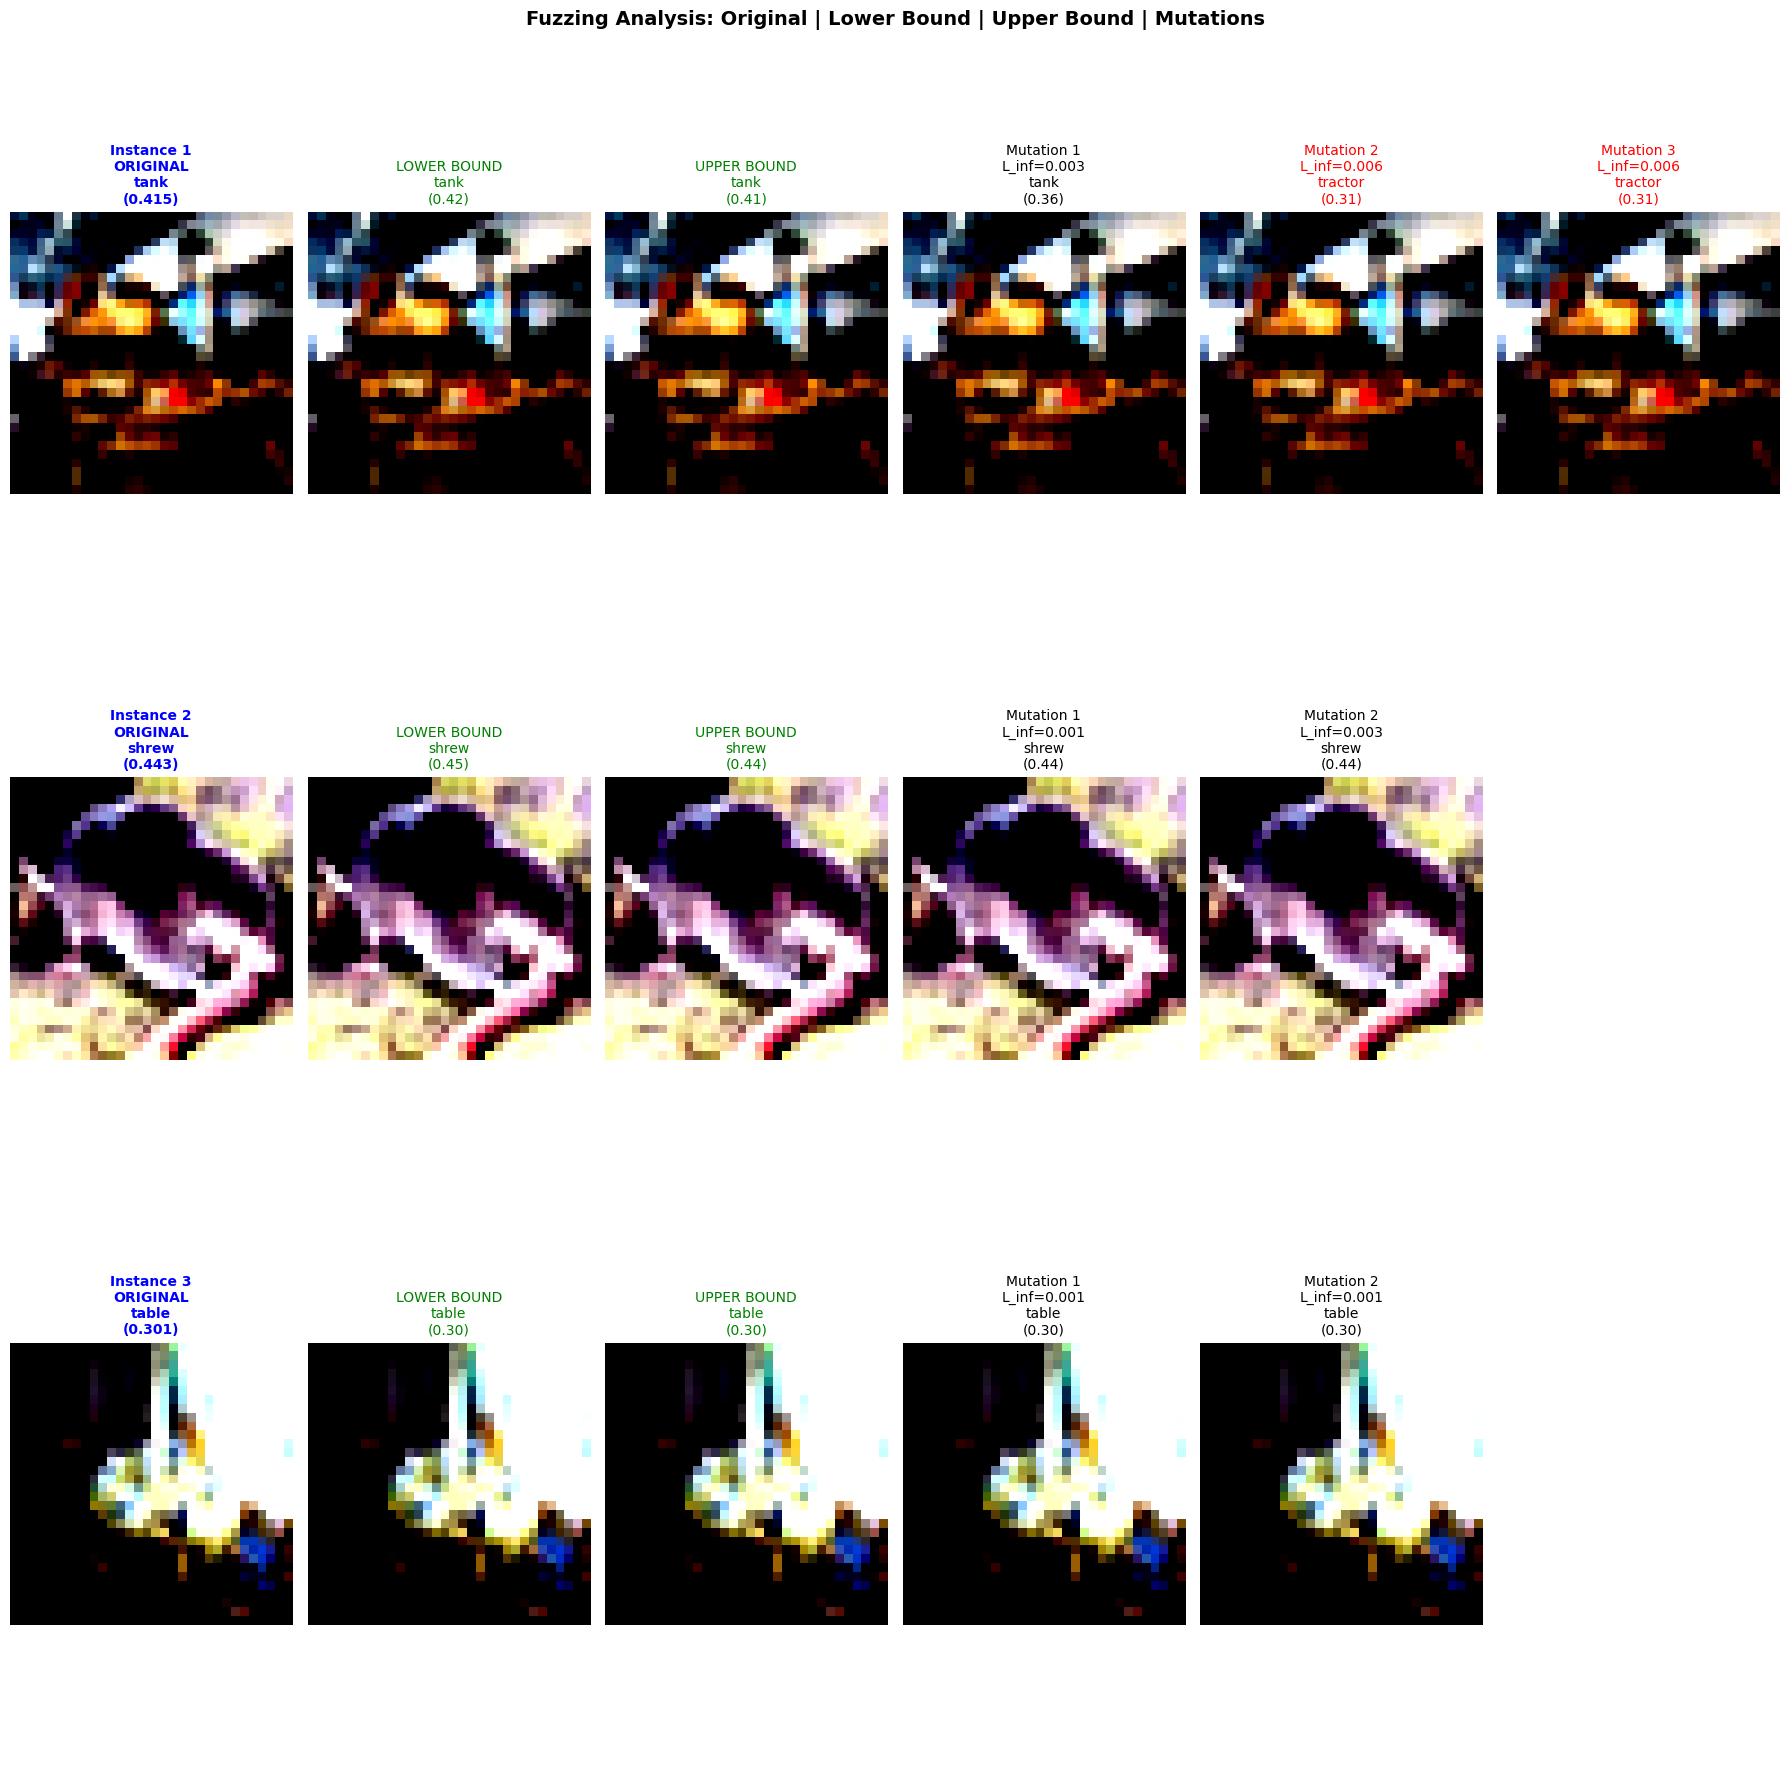


Tested 3 instances
Found 1249 counterexamples!


In [4]:
print("="*80)
print("FUZZING VISUALIZATION")
print("="*80)

num_instances = len(instance_info)

# One row per instance: Original | LB | UB | 3 Mutations
fig, axes = plt.subplots(num_instances, 6, figsize=(18, 6 * num_instances))
if num_instances == 1:
    axes = axes.reshape(1, -1)

for inst_idx, info in enumerate(instance_info):
    input_tensor = info['input_tensor']
    true_label = info['true_label']
    input_spec = info['input_spec']
    epsilon = info['epsilon']
    wrapped_model = wrapped_models_list[inst_idx]
    instance_fuzzer = all_fuzzers[inst_idx]
    instance_corpus_seeds = list(instance_fuzzer.seed_corpus.seeds)
    
    # Ensure 3D tensor
    if input_tensor.dim() == 4:
        input_tensor = input_tensor.squeeze(0)
    
    # Get original prediction
    input_batch = input_tensor.unsqueeze(0)
    with torch.no_grad():
        orig_output = wrapped_model(input_batch)
        if isinstance(orig_output, dict):
            orig_output = orig_output['output']
        orig_pred = orig_output.argmax(dim=1).item()
        orig_probs = torch.softmax(orig_output[0], dim=0)
        orig_conf = orig_probs[orig_pred].item()
    
    # Column 0: Original
    orig_img = input_tensor.reshape(3, 32, 32).permute(1, 2, 0)
    orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
    axes[inst_idx, 0].imshow(orig_img_np, interpolation='nearest')
    axes[inst_idx, 0].set_title(f'Instance {inst_idx+1}\nORIGINAL\n{CIFAR100_CLASSES[true_label]}\n({orig_conf:.3f})',
                                 fontsize=10, color='blue', fontweight='bold')
    axes[inst_idx, 0].axis('off')
    
    # Column 1: Lower Bound
    lb_tensor = input_spec.lb
    if lb_tensor.dim() == 4:
        lb_tensor = lb_tensor.squeeze(0)
    lb_tensor = lb_tensor.reshape(3, 32, 32)
    lb_img = lb_tensor.permute(1, 2, 0)
    lb_img_np = np.clip(lb_img.cpu().numpy(), 0, 1)
    axes[inst_idx, 1].imshow(lb_img_np, interpolation='nearest')
    
    with torch.no_grad():
        lb_output = wrapped_model(lb_tensor.unsqueeze(0))
        if isinstance(lb_output, dict):
            lb_output = lb_output['output']
        lb_pred = lb_output.argmax(dim=1).item()
        lb_probs = torch.softmax(lb_output[0], dim=0)
        lb_conf = lb_probs[lb_pred].item()
    
    axes[inst_idx, 1].set_title(f'LOWER BOUND\n{CIFAR100_CLASSES[lb_pred]}\n({lb_conf:.2f})',
                                 fontsize=10, color='red' if lb_pred != true_label else 'green')
    axes[inst_idx, 1].axis('off')
    
    # Column 2: Upper Bound
    ub_tensor = input_spec.ub
    if ub_tensor.dim() == 4:
        ub_tensor = ub_tensor.squeeze(0)
    ub_tensor = ub_tensor.reshape(3, 32, 32)
    ub_img = ub_tensor.permute(1, 2, 0)
    ub_img_np = np.clip(ub_img.cpu().numpy(), 0, 1)
    axes[inst_idx, 2].imshow(ub_img_np, interpolation='nearest')
    
    with torch.no_grad():
        ub_output = wrapped_model(ub_tensor.unsqueeze(0))
        if isinstance(ub_output, dict):
            ub_output = ub_output['output']
        ub_pred = ub_output.argmax(dim=1).item()
        ub_probs = torch.softmax(ub_output[0], dim=0)
        ub_conf = ub_probs[ub_pred].item()
    
    axes[inst_idx, 2].set_title(f'UPPER BOUND\n{CIFAR100_CLASSES[ub_pred]}\n({ub_conf:.2f})',
                                 fontsize=10, color='red' if ub_pred != true_label else 'green')
    axes[inst_idx, 2].axis('off')
    
    # Columns 3-5: Mutations from corpus
    instance_seeds = []
    for seed in instance_corpus_seeds:
        seed_tensor = seed.tensor
        if seed_tensor.dim() == 4:
            seed_tensor = seed_tensor.squeeze(0)
        seed_tensor = seed_tensor.reshape(3, 32, 32).to(input_tensor.device)
        dist = (seed_tensor - input_tensor.reshape(3, 32, 32)).abs().max().item()
        if dist > 1e-6 and dist <= epsilon * 2:
            instance_seeds.append((seed, dist))
    
    instance_seeds.sort(key=lambda x: x[1])
    instance_seeds = instance_seeds[:3]
    
    for seed_idx, (seed, dist) in enumerate(instance_seeds):
        col = 3 + seed_idx
        seed_tensor = seed.tensor
        if seed_tensor.dim() == 4:
            seed_tensor = seed_tensor.squeeze(0)
        seed_tensor = seed_tensor.reshape(3, 32, 32)
        img = seed_tensor.permute(1, 2, 0)
        img_np = np.clip(img.cpu().numpy(), 0, 1)
        
        seed_tensor = seed_tensor.to(input_tensor.device)
        diff = seed_tensor - input_tensor.reshape(3, 32, 32)
        l_inf = diff.abs().max().item()
        
        with torch.no_grad():
            seed_output = wrapped_model(seed_tensor.unsqueeze(0))
            if isinstance(seed_output, dict):
                seed_output = seed_output['output']
            seed_pred = seed_output.argmax(dim=1).item()
            seed_probs = torch.softmax(seed_output[0], dim=0)
            seed_conf = seed_probs[seed_pred].item()
        
        axes[inst_idx, col].imshow(img_np, interpolation='nearest')
        title_color = 'red' if seed_pred != true_label else 'black'
        axes[inst_idx, col].set_title(f'Mutation {seed_idx+1}\nL_inf={l_inf:.3f}\n{CIFAR100_CLASSES[seed_pred]}\n({seed_conf:.2f})',
                                      fontsize=10, color=title_color)
        axes[inst_idx, col].axis('off')
    
    # Fill empty columns
    for empty_col in range(3 + len(instance_seeds), 6):
        axes[inst_idx, empty_col].axis('off')

plt.suptitle('Fuzzing Analysis: Original | Lower Bound | Upper Bound | Mutations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print(f"\nTested {len(instance_info)} instances")
print(f"All mutations maintained correct classification" if total_counterexamples == 0 else f"Found {total_counterexamples} counterexamples!")

## Step 4: Convert to ACT Net for Verification

In [5]:
print("="*80)
print("CONVERTING TO ACT NET")
print("="*80)

# Use first instance for verification demo
demo_idx = 0
wrapped_model = wrapped_models_list[demo_idx]
info = instance_info[demo_idx]
input_tensor = info['input_tensor']
true_label = info['true_label']
input_spec = info['input_spec']
epsilon = info['epsilon']

print(f"Demo instance: {CIFAR100_CLASSES[true_label]} (label={true_label})")

# Convert to ACT Net
converter = TorchToACT(wrapped_model)
act_net = converter.run()

print(f"ACT layers: {len(act_net.layers)}")
print(f"Variables: {converter.next_var}")

# Show network structure summary
print(f"\nNetwork structure (first 5 and last 3 layers):")
for i, layer in enumerate(act_net.layers[:5]):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")
print("  ...")
for i, layer in enumerate(act_net.layers[-3:], len(act_net.layers)-3):
    print(f"  {i:2d}. {layer.kind:15s} | Out vars: {len(layer.out_vars):6d}")

CONVERTING TO ACT NET
Demo instance: tank (label=85)
ACT layers: 73
Variables: 246700

Network structure (first 5 and last 3 layers):
   0. INPUT           | Out vars:   3072
   1. INPUT_SPEC      | Out vars:   3072
   2. CONV2D          | Out vars:  14400
   3. SCALE           | Out vars:  14400
   4. BIAS            | Out vars:  14400
  ...
  70. RELU            | Out vars:    100
  71. DENSE           | Out vars:    100
  72. ASSERT          | Out vars:    100


## Step 5: IntervalTF - Layer-by-Layer Bounds Propagation

INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)
Input bounds: lb=[-1.8824, 1.9682], ub=[-1.8531, 1.9966]

Running forward interval propagation...
Computed bounds for 73 layers

Layer  Kind                Vars  Width(mean)   Width(max)
-------------------------------------------------------
0      INPUT               3072       0.0294       0.0306
1      INPUT_SPEC          3072       0.0294       0.0306
2      CONV2D             14400       0.1273       0.3711
3      SCALE              14400       0.0833       0.2984
4      BIAS               14400       0.0833       0.2984
5      RELU               14400       0.0833       0.2984
6      CONV2D              8192       1.1273       6.1086
7      SCALE               8192       0.1810       0.8373
8      BIAS                8192       0.1810       0.8373
9      RELU                8192       0.1810       0.8373
...
68     FLATTEN              512       0.0000       0.0000
69     DENSE                100       0.0000       0.0000
70     RELU 

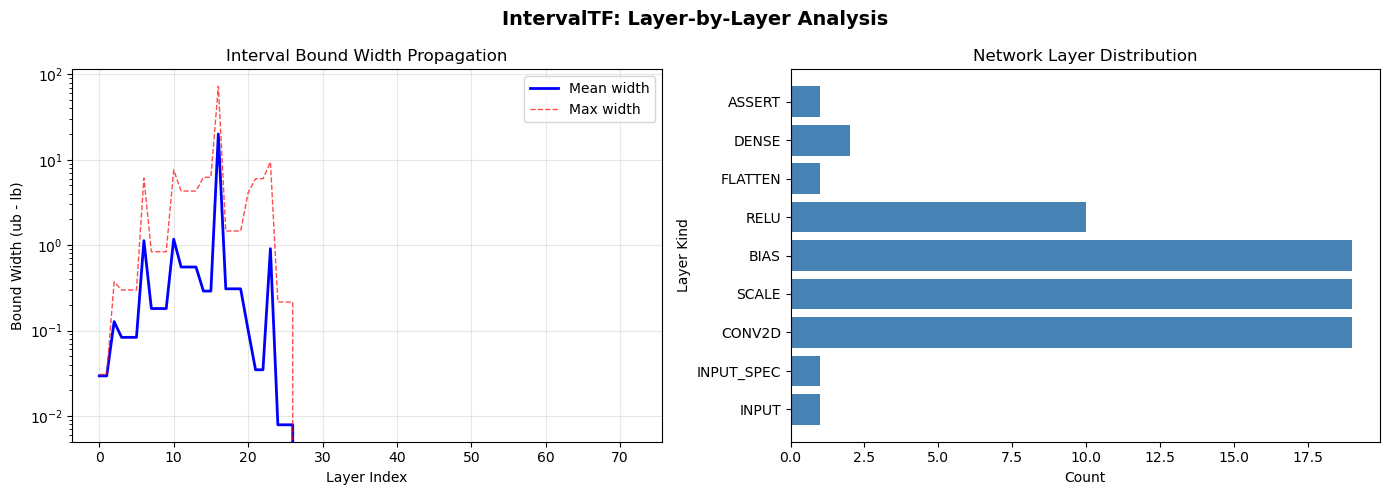


Key Observations:
  Input bound width (mean): 0.029446
  Output bound width (mean): 0.000000
  Bound expansion ratio: 0.00x

Output layer bounds:
  Shape: torch.Size([100])
  lb range: [-3.0816, -0.2668]
  ub range: [-3.0816, -0.2668]


In [6]:
print("="*80)
print("INTERVAL BOUNDS PROPAGATION (Layer-by-Layer)")
print("="*80)

# Create input bounds from epsilon
if input_tensor.dim() == 4:
    input_flat = input_tensor.squeeze(0).flatten()
else:
    input_flat = input_tensor.flatten()

# Use bounds from input_spec
input_lb = input_spec.lb.flatten()
input_ub = input_spec.ub.flatten()

print(f"Input bounds: lb=[{input_lb.min():.4f}, {input_lb.max():.4f}], ub=[{input_ub.min():.4f}, {input_ub.max():.4f}]")

# Compute forward bounds
print("\nRunning forward interval propagation...")
bounds_dict = compute_forward_bounds(act_net, input_lb, input_ub)
print(f"Computed bounds for {len(bounds_dict)} layers")

# Collect layer statistics
layer_stats = []
for layer in act_net.layers:
    bounds = bounds_dict.get(layer.id)
    if bounds is not None:
        lb, ub = bounds.lb, bounds.ub
        width = (ub - lb)
        layer_stats.append({
            'id': layer.id,
            'kind': layer.kind,
            'num_vars': len(lb.flatten()),
            'width_mean': width.mean().item(),
            'width_max': width.max().item(),
            'lb_range': f"[{lb.min().item():.3f}, {lb.max().item():.3f}]",
            'ub_range': f"[{ub.min().item():.3f}, {ub.max().item():.3f}]",
        })

# Print table
print(f"\n{'Layer':<6} {'Kind':<15} {'Vars':>8} {'Width(mean)':>12} {'Width(max)':>12}")
print("-"*55)
for s in layer_stats[:10]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")
if len(layer_stats) > 15:
    print("...")
for s in layer_stats[-5:]:
    print(f"{s['id']:<6} {s['kind']:<15} {s['num_vars']:>8} {s['width_mean']:>12.4f} {s['width_max']:>12.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bound width evolution
layer_indices = range(len(layer_stats))
mean_widths = [s['width_mean'] for s in layer_stats]
max_widths = [s['width_max'] for s in layer_stats]

axes[0].plot(layer_indices, mean_widths, 'b-', label='Mean width', linewidth=2)
axes[0].plot(layer_indices, max_widths, 'r--', label='Max width', linewidth=1, alpha=0.7)
axes[0].set_xlabel('Layer Index')
axes[0].set_ylabel('Bound Width (ub - lb)')
axes[0].set_title('Interval Bound Width Propagation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Layer kind distribution
kind_counts = Counter([s['kind'] for s in layer_stats])
kinds = list(kind_counts.keys())
counts = list(kind_counts.values())
axes[1].barh(kinds, counts, color='steelblue')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Layer Kind')
axes[1].set_title('Network Layer Distribution')

plt.suptitle('IntervalTF: Layer-by-Layer Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key observations
print(f"\nKey Observations:")
print(f"  Input bound width (mean): {layer_stats[0]['width_mean']:.6f}")
print(f"  Output bound width (mean): {layer_stats[-1]['width_mean']:.6f}")
expansion_ratio = layer_stats[-1]['width_mean'] / (layer_stats[0]['width_mean'] + 1e-10)
print(f"  Bound expansion ratio: {expansion_ratio:.2f}x")

# Store output bounds for DualTF
output_layer = act_net.layers[-2]  # Before ASSERT
output_bounds = bounds_dict.get(output_layer.id)
if output_bounds:
    print(f"\nOutput layer bounds:")
    print(f"  Shape: {output_bounds.lb.shape}")
    print(f"  lb range: [{output_bounds.lb.min():.4f}, {output_bounds.lb.max():.4f}]")
    print(f"  ub range: [{output_bounds.ub.min():.4f}, {output_bounds.ub.max():.4f}]")

## Step 6: DualTF - Robust Classification Bound

In [7]:
print("="*80)
print("DUAL TF VERIFICATION")
print("="*80)

dual_tf = DualTF()
num_classes = 100

# Compute robust bound
min_margin, is_certified = dual_tf.compute_robust_bound(act_net, bounds_dict, true_label, num_classes)

print(f"\nRobust verification result:")
print(f"  True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Status: {'CERTIFIED' if is_certified else 'NOT CERTIFIED'}")

# Compute detailed margins for top adversarial classes
print(f"\nDetailed margins for top adversarial classes:")

# Get model prediction to find top classes
if input_tensor.dim() == 3:
    input_batch = input_tensor.unsqueeze(0)
else:
    input_batch = input_tensor

with torch.no_grad():
    orig_output = wrapped_model(input_batch)
    if isinstance(orig_output, dict):
        orig_output = orig_output['output']
    orig_pred = orig_output.argmax(dim=1).item()
    orig_conf = torch.softmax(orig_output[0], dim=0)[orig_pred].item()
    top10_classes = torch.topk(orig_output[0], k=10).indices.tolist()

print(f"\nOriginal prediction: {CIFAR100_CLASSES[orig_pred]} (conf: {orig_conf:.3f})")
print(f"Top 10 classes: {top10_classes}")

# Compute margins
margins = []
for target_class in top10_classes:
    if target_class == true_label:
        continue
    
    c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
    c[true_label] = 1.0
    c[target_class] = -1.0
    
    margin = dual_tf.compute_bound(act_net, bounds_dict, c)
    margins.append((target_class, margin.item()))
    
    status = "OK" if margin.item() > 0 else "VULNERABLE"
    print(f"  Class {target_class:3d} ({CIFAR100_CLASSES[target_class]:20s}): margin = {margin.item():8.4f} [{status}]")

# Find most vulnerable class
margins.sort(key=lambda x: x[1])
weakest_class, weakest_margin = margins[0]
print(f"\nMost vulnerable adversarial class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"Margin: {weakest_margin:.6f}")

DUAL TF VERIFICATION

Robust verification result:
  True label: 85 (tank)
  Min margin: -2.224983
  Status: NOT CERTIFIED

Detailed margins for top adversarial classes:

Original prediction: tank (conf: 0.415)
Top 10 classes: [85, 89, 51, 37, 15, 58, 91, 17, 13, 26]
  Class  89 (tractor             ): margin =   1.0659 [OK]
  Class  51 (mushroom            ): margin =  -1.5691 [VULNERABLE]
  Class  37 (house               ): margin =  -0.8568 [VULNERABLE]
  Class  15 (camel               ): margin =  -0.6875 [VULNERABLE]
  Class  58 (pickup_truck        ): margin =   0.5949 [OK]
  Class  91 (trout               ): margin =  -0.6166 [VULNERABLE]
  Class  17 (castle              ): margin =   1.6071 [OK]
  Class  13 (bus                 ): margin =   1.4352 [OK]
  Class  26 (crab                ): margin =  -0.5105 [VULNERABLE]

Most vulnerable adversarial class: 51 (mushroom)
Margin: -1.569103


## Step 7: Spurious Counterexample (SCE) Analysis

SPURIOUS COUNTEREXAMPLE (SCE) ANALYSIS
Target adversarial class: 51 (mushroom)
DualTF margin: -1.569103
SCE raw shape: torch.Size([2883])
SCE size mismatch (2883 vs 3072), using input bounds for reconstruction...
Using input lower bound as SCE
SCE image shape: torch.Size([1, 3, 32, 32])

SCE inference result:
  Predicted class: 85 (tank)
  Confidence: 0.4221
  Target class (mushroom) confidence: 0.0628


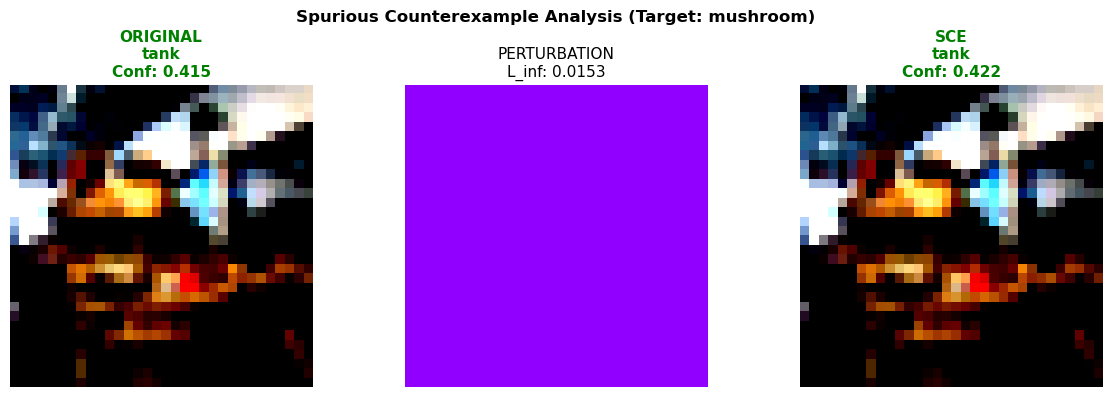


SCE ANALYSIS SUMMARY
Original: tank (conf: 0.415)
SCE prediction: tank (conf: 0.422)
Target class: mushroom
Perturbation L_inf: 0.015295
Within epsilon (0.030590): True

RESULT: SCE maintains correct classification
  This is a SPURIOUS counterexample (greedy boundary selection)
  Real adversarial may exist but requires more sophisticated search


In [8]:
print("="*80)
print("SPURIOUS COUNTEREXAMPLE (SCE) ANALYSIS")
print("="*80)

# Get SCE for most vulnerable adversarial class
c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
c[true_label] = 1.0
c[weakest_class] = -1.0

# Compute bound with SCE
margin, sce_raw = dual_tf.compute_bound(act_net, bounds_dict, c, return_sce=True)

print(f"Target adversarial class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"DualTF margin: {margin.item():.6f}")
print(f"SCE raw shape: {sce_raw.shape}")

# Handle SCE shape mismatch - reconstruct using input bounds if needed
expected_size = 3 * 32 * 32  # 3072 for CIFAR images
if sce_raw.numel() != expected_size:
    print(f"SCE size mismatch ({sce_raw.numel()} vs {expected_size}), using input bounds for reconstruction...")
    input_layer = act_net.layers[1]  # INPUT_SPEC layer
    input_bounds = bounds_dict.get(input_layer.id)
    if input_bounds is not None:
        # Use lower bound as counterexample (greedy selection)
        sce_image = input_bounds.lb.clone().reshape(1, 3, 32, 32)
        print(f"Using input lower bound as SCE")
    else:
        print("ERROR: Cannot reconstruct SCE - no input bounds available")
        sce_image = input_tensor.clone()  # Fallback to original input
else:
    sce_image = sce_raw.reshape(1, 3, 32, 32)

print(f"SCE image shape: {sce_image.shape}")

# Extract PyTorch model to avoid dtype issues with wrapped model
pytorch_model = wrapped_model[2]
pytorch_model.eval()

# Run model inference on SCE
with torch.no_grad():
    sce_output = pytorch_model(sce_image)
    sce_pred = sce_output.argmax(dim=1).item()
    sce_probs = torch.softmax(sce_output[0], dim=0)
    sce_conf = sce_probs[sce_pred].item()
    sce_target_conf = sce_probs[weakest_class].item()

print(f"\nSCE inference result:")
print(f"  Predicted class: {sce_pred} ({CIFAR100_CLASSES[sce_pred]})")
print(f"  Confidence: {sce_conf:.4f}")
print(f"  Target class ({CIFAR100_CLASSES[weakest_class]}) confidence: {sce_target_conf:.4f}")

# Visualization: Original vs SCE
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original image
if input_tensor.dim() == 4:
    orig_tensor = input_tensor.squeeze(0)
else:
    orig_tensor = input_tensor
orig_img = orig_tensor.reshape(3, 32, 32).permute(1, 2, 0)
orig_img_np = np.clip(orig_img.cpu().numpy(), 0, 1)
axes[0].imshow(orig_img_np, interpolation='nearest')
axes[0].set_title(f'ORIGINAL\n{CIFAR100_CLASSES[true_label]}\nConf: {orig_conf:.3f}', 
                  fontsize=11, color='green', fontweight='bold')
axes[0].axis('off')

# Perturbation (SCE - Original)
diff = sce_image.squeeze() - orig_tensor.reshape(3, 32, 32).to(sce_image.device)
diff_img = diff.permute(1, 2, 0).cpu().numpy()
diff_vis = (diff_img - diff_img.min()) / (diff_img.max() - diff_img.min() + 1e-8)
axes[1].imshow(diff_vis, interpolation='nearest')
l_inf = diff.abs().max().item()
axes[1].set_title(f'PERTURBATION\nL_inf: {l_inf:.4f}', fontsize=11)
axes[1].axis('off')

# SCE image
sce_img = sce_image.squeeze().permute(1, 2, 0)
sce_img_np = np.clip(sce_img.cpu().numpy(), 0, 1)
axes[2].imshow(sce_img_np, interpolation='nearest')
color = 'red' if sce_pred != true_label else 'green'
axes[2].set_title(f'SCE\n{CIFAR100_CLASSES[sce_pred]}\nConf: {sce_conf:.3f}', 
                  fontsize=11, color=color, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'Spurious Counterexample Analysis (Target: {CIFAR100_CLASSES[weakest_class]})', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Analysis summary
print(f"\n" + "="*60)
print("SCE ANALYSIS SUMMARY")
print("="*60)
print(f"Original: {CIFAR100_CLASSES[true_label]} (conf: {orig_conf:.3f})")
print(f"SCE prediction: {CIFAR100_CLASSES[sce_pred]} (conf: {sce_conf:.3f})")
print(f"Target class: {CIFAR100_CLASSES[weakest_class]}")
print(f"Perturbation L_inf: {l_inf:.6f}")
print(f"Within epsilon ({epsilon:.6f}): {l_inf <= epsilon}")

if sce_pred != true_label:
    if sce_pred == weakest_class:
        print(f"\nRESULT: SCE causes misclassification to TARGET class!")
    else:
        print(f"\nRESULT: SCE causes misclassification to different class: {CIFAR100_CLASSES[sce_pred]}")
else:
    print(f"\nRESULT: SCE maintains correct classification")
    print(f"  This is a SPURIOUS counterexample (greedy boundary selection)")
    print(f"  Real adversarial may exist but requires more sophisticated search")

## Step 8: Results Summary

In [9]:
print("\n" + "="*80)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*80)

print(f"\n[Model Information]")
print(f"  Benchmark: cifar100_2024")
print(f"  Instances tested: {len(instance_info)}")
print(f"  Demo instance: {CIFAR100_CLASSES[true_label]} (label={true_label})")
print(f"  Epsilon: {epsilon:.6f}")

print(f"\n[Fuzzing Results]")
print(f"  Total iterations: {total_iterations}")
print(f"  Total time: {total_time:.2f}s")
print(f"  Average coverage: {avg_coverage:.2%}")
print(f"  Counterexamples found: {total_counterexamples}")

print(f"\n[IntervalTF Results]")
print(f"  Layers analyzed: {len(layer_stats)}")
print(f"  Input bound width: {layer_stats[0]['width_mean']:.6f}")
print(f"  Output bound width: {layer_stats[-1]['width_mean']:.6f}")

print(f"\n[DualTF Verification]")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Certified: {is_certified}")
print(f"  Most vulnerable class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")

print(f"\n[SCE Analysis]")
print(f"  SCE prediction: {CIFAR100_CLASSES[sce_pred]}")
print(f"  Misclassification: {sce_pred != true_label}")
print(f"  Perturbation L_inf: {l_inf:.6f}")

print(f"\n[Conclusion]")
if is_certified:
    print(f"  Model is CERTIFIED ROBUST for this instance")
elif total_counterexamples > 0:
    print(f"  Model is NOT ROBUST - fuzzing found counterexamples")
else:
    print(f"  Model is NOT CERTIFIED but no counterexamples found by fuzzing")
    print(f"  Further analysis with SCE or increased fuzzing budget recommended")

print("\n" + "="*80)
print("DEMO COMPLETE")
print("="*80)


COMPREHENSIVE RESULTS SUMMARY

[Model Information]
  Benchmark: cifar100_2024
  Instances tested: 3
  Demo instance: tank (label=85)
  Epsilon: 0.030590

[Fuzzing Results]
  Total iterations: 3676
  Total time: 180.17s
  Average coverage: 55.36%
  Counterexamples found: 1249

[IntervalTF Results]
  Layers analyzed: 73
  Input bound width: 0.029446
  Output bound width: 0.000000

[DualTF Verification]
  Min margin: -2.224983
  Certified: False
  Most vulnerable class: 51 (mushroom)

[SCE Analysis]
  SCE prediction: tank
  Misclassification: False
  Perturbation L_inf: 0.015295

[Conclusion]
  Model is NOT ROBUST - fuzzing found counterexamples

DEMO COMPLETE
